# CP1 - Statistical Computing with R & Python.
## Parte 1 - Coleta, Exploração, Tratamento e Validação dos Dados.
### Dataset: IRIS.

**Integrantes:**

- Rafael Medici | RM: 576249
- Gustavo Carreiro | RM: 576379
- Ludson Rodrigo Marciano Fernandes | RM: 574997
- Lucas Longo Rosette | RM: 576306
- Kayky Cayres Vicente da Silva | RM: 575091

## 1. Coleta dos dados e fonte utilizada.

O Dataset utilizado é o **IRIS**, um dos conjuntos de dados mais conhecidos em Machine Learning. Ele está disponível nativamente na biblioteca `scikit-learn`, não sendo necessário download externo.

Contém **150 amostras** de flores, divididas em **3 espécies** (*setosa*, *versicolor*, *virginica*), com **4 atributos numéricos** medidos em centímetros: comprimento e largura da sépala e da pétala.

In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Carregamento do Dataset IRIS diretamente do scikit-learn
iris = load_iris(as_frame=True)
df = iris.frame.copy()

# Criação de uma coluna com o nome da espécie (mais legível que o número da classe)
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# Visualização das primeiras linhas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploração dos dados.

Antes de qualquer tratamento, é preciso entender o formato e as características do Dataset: quantidade de registros, tipos de dados e distribuição das classes.

In [ ]:
# Dimensões do dataset: (número de linhas, número de colunas)
print("Dimensões do dataset:", df.shape)
print()

# Tipos de dados de cada coluna
df.info()

Dimensões do dataset: (150, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
# Estatísticas descritivas das variáveis numéricas (média, desvio-padrão, mínimo, máximo, quartis)
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
# Verificação do balanceamento das classes (quantidade de amostras por espécie)
print("Distribuição das classes (espécies):")
df['species'].value_counts()

Distribuição das classes (espécies):


,count
species,
setosa,50
versicolor,50
virginica,50


## 3. Estrutura e características dos dados.

Com base na exploração acima, resume-se o Dataset da seguinte forma:

- **150 registros**, **4 variáveis preditoras numéricas contínuas** (todas em centímetros) e **1 variável alvo categórica** (espécie).
- **3 classes perfeitamente balanceadas** (50 amostras cada), o que é favorável para evitar viés na etapa de classificação.
- Todas as variáveis estão na **mesma unidade de medida**, o que favorece o uso de algoritmos baseados em distância - como o KNN, que será utilizado na Parte 2.

## 4. Identificação e Tratamento de valores ausentes.

Verifica-se a existência de células vazias (valores nulos/NaN) em cada coluna do Dataset.

In [ ]:
# Contagem de valores ausentes (nulos) por coluna
valores_ausentes = df.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes)
print()
print("Total de valores ausentes no dataset:", valores_ausentes.sum())

Valores ausentes por coluna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Total de valores ausentes no dataset: 0


**Resultado:** Não há valores ausentes no Dataset. Ainda assim, a verificação foi realizada como parte do processo padrão de validação de qualidade de dados — caso houvesse valores ausentes, o tratamento indicado seria a remoção da linha ou a imputação pela média/mediana da coluna, por espécie.

## 5. Identificação e tratamento de duplicidades

Verifica-se a existência de linhas duplicadas — ou seja, duas flores **DA MESMA ESPÉCIE** com exatamente as mesmas quatro medidas.

In [ ]:
# Contagem de linhas duplicadas
duplicatas = df.duplicated().sum()
print("Número de linhas duplicadas:", duplicatas)

if duplicatas > 0:
    print("\nLinhas duplicadas encontradas:")
    display(df[df.duplicated(keep=False)])
    # Remoção das duplicatas, mantendo apenas a primeira ocorrência
    df = df.drop_duplicates().reset_index(drop=True)
    print("\nDuplicatas removidas. Novo shape:", df.shape)
else:
    print("Nenhuma duplicata encontrada — nenhum tratamento necessário.")

Número de linhas duplicadas: 1

Linhas duplicadas encontradas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
101,5.8,2.7,5.1,1.9,2,virginica
142,5.8,2.7,5.1,1.9,2,virginica



Duplicatas removidas. Novo shape: (149, 6)


## 6. Identificação e Tratamento de Inconsistências

A verificação de Inconsistências é feita em duas frentes:

1. **Impossibilidade física:** Nenhuma medida pode ser menor ou igual a zero (não existe pétala com comprimento negativo, por exemplo).
2. **Outliers estatísticos:** Valores muito fora do padrão de cada coluna, identificados pelo método do Intervalo Interquartil (IQR).

In [ ]:
colunas_numericas = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Verificação de valores fisicamente impossíveis (<= 0)
inconsistencias = (df[colunas_numericas] <= 0).sum()
print("Valores <= 0 por coluna (inconsistência física):")
print(inconsistencias)

Valores <= 0 por coluna (inconsistência física):
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


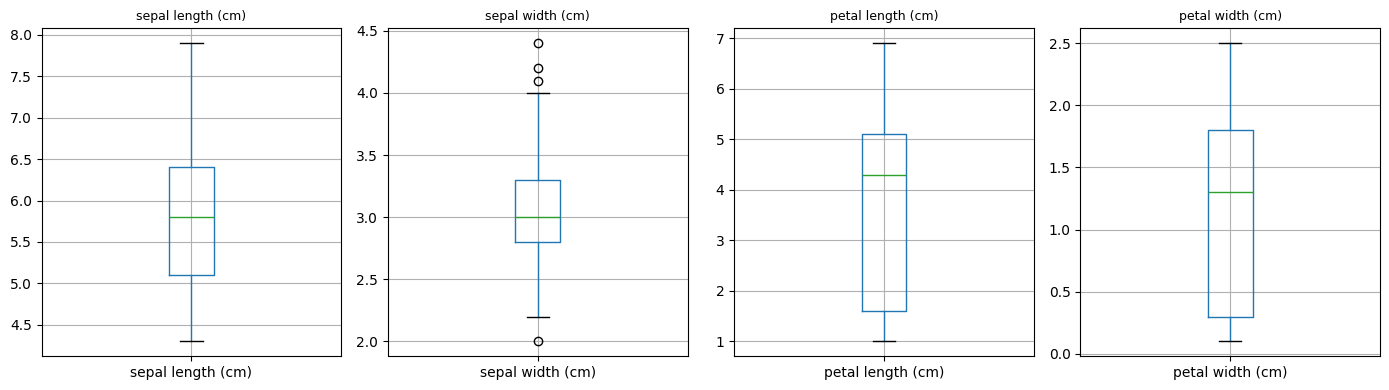

In [ ]:
import matplotlib.pyplot as plt

# Boxplot de cada variável numérica para identificação visual de outliers
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, colunas_numericas):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Estatísticas de referência para justificar os pontos identificados como outliers no boxplot
col = 'sepal width (cm)'

print(f"Média geral de {col}: {df[col].mean():.2f} cm")
print(f"Desvio padrão geral: {df[col].std():.2f} cm")
print()
print(f"Média de {col} por espécie:")
print(df.groupby('species')[col].mean().round(2))
print()

# Os valores mais extremos da coluna, que aparecem como pontos isolados fora dos "bigodes" no boxplot
print("Valores mais altos (maiores extremos observados no boxplot):")
print(df.nlargest(3, col)[[col, 'species']])
print()
print("Valores mais baixos (menores extremos observados no boxplot):")
print(df.nsmallest(1, col)[[col, 'species']])

Média geral de sepal width (cm): 3.06 cm
Desvio padrão geral: 0.44 cm

Média de sepal width (cm) por espécie:
species
setosa        3.43
versicolor    2.77
virginica     2.98
Name: sepal width (cm), dtype: float64

Valores mais altos (maiores extremos observados no boxplot):
    sepal width (cm) species
15               4.4  setosa
33               4.2  setosa
32               4.1  setosa

Valores mais baixos (menores extremos observados no boxplot):
    sepal width (cm)     species
60               2.0  versicolor


**Resultado e decisão tomada:** Não há valores fisicamente impossíveis. No boxplot, observam-se alguns pontos isolados (outliers) em `sepal width (cm)`: A espécie *setosa* tem, em média, sépala mais larga que as demais (3,43 cm contra 2,77 e 2,97 cm), o que explica os pontos mais altos; um único caso de *versicolor* aparece abaixo do padrão. A decisão foi **manter esses registros**, pois são variações naturais entre indivíduos da mesma espécie, e não erros de coleta ou medição.


## 7. Análise da qualidade dos dados tratados e adequação para a próxima etapa.

Com base em todas as verificações realizadas, conclui-se que:

- Não há **valores ausentes** no Dataset.
- Não há **linhas duplicadas**.
- Não há **inconsistências físicas** (valores ≤ 0); os outliers estatísticos identificados foram investigados e mantidos, por representarem variação natural e não erro.
- A distribuição final (49 amostras de virginica contra 50 das demais) reflete a remoção da linha duplicada identificada na etapa anterior.
- Todas as variáveis são **numéricas contínuas** e estão na **mesma escala** (centímetros), o que favorece algoritmos baseados em distância.

**Conclusão:** o Dataset está limpo, consistente e adequado para a próxima etapa do projeto — a aplicação de técnicas de Machine Learning (Parte 2). A única preparação adicional necessária será a **padronização das variáveis**, que faz parte da etapa de preparação para o modelo, e não do processo de limpeza dos dados.

# CP1 - Machine Learning & Modelling.
## Parte 2 - Modelo, treinamento, teste e tabela de acurácia

## 1. Preparação do modelo
Aqui importamos tudo que o modelo precisará, separamos os dados que tratamos e definimos a parte de treinamento e teste, utilizamos 70% da base para treino e os outros 30% para teste, decidimos a semente 42 para melhor reprodutibilidade e o stratify para a proporção das classes serem sempre as mesmas.

In [ ]:
# Importação das bibliotecas necessárias
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Separação das features e do target
X, y = df[colunas_numericas], df['target']

# Separação de treino e teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # random_state ==> fixa a divisão para o resultado ser sempre igual  stratify ==> mantém a proporção de cada classe em treino e teste
)

## Treino e teste
Fizemos um loop para tornar mais prático a mundança dos K, aqui o modelo é chamado com o K definido no loop, ele treina e depois fazemos o teste de acurácia dele, esse resultado é retornado para uma lista vazia que futuramente será a tabela de comparação de acurácia.

A métrica utilizada para avaliar cada modelo é a acuracia: a proporção de previsões corretas sobre o total de previsões feitas no conjunto de testes.

In [ ]:
# Essa lista será a tabela de acurácia no final
resultados_k = []

# O loop trocará o valor do K toda volta
for k in [1, 3, 5, 7, 9]:
    modelo = KNeighborsClassifier(n_neighbors=k) # Cria um modelo novo em cada loop
    modelo.fit(X_train, y_train) # Treina o modelo
    pred = modelo.predict(X_test) # Testa o modelo treinado
    acc = accuracy_score(y_test, pred) # Compara o resultado esperado com o pred
    resultados_k.append({"K": k, "acuracia": round(acc, 4)}) # Retorna o resultado para a lista

## Tabela de acurácia
A biblioteca pandas transforma a lista, que agora tem os valores dos resultados do modelo, em uma tabela para termos uma melhor visualização.

In [ ]:
tabela_k = pd.DataFrame(resultados_k) # Transforma a lista em uma tabela
tabela_k

,K,acuracia
0,1,0.9333
1,3,0.9556
2,5,0.9778
3,7,0.9556
4,9,0.9556


# EXTRA
Trouxemos alguns extras sobre o K e suas vertentes
## Validação cruzada
Aqui um método de validação cruzada é usado para descobrirmos um K mais confiável. O treino agora é subdividido em partes, uma delas sendo separada para validação interna de treino, essa parte de validação é trocada a cada ciclo. Cada K é avaliado 5 vezes dentro do treino e só depois o melhor K é avaliado no teste final.

In [ ]:
# Importa o método de validação cruzada
from sklearn.model_selection import cross_val_score

resultados_cv = []

for k in [1, 3, 5, 7, 9, 75, 83]:
    notas = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5) # Executa a mesma tarefa da troca do K manualmente, mas agora 5 vezes e automaticamente
    resultados_cv.append({"K": k, "media_cv": round(notas.mean(), 4), "desvio_cv": round(notas.std(), 4)}) # Retorna os valores para a lista vazia

tabela_cv_loop = pd.DataFrame(resultados_cv) # Transforma a lista com os resultados em uma tabela
melhor_k_loop = int(tabela_cv_loop.loc[tabela_cv_loop["media_cv"].idxmax(), "K"]) # Procura e coleta o melhor K com base na média, em caso de empate o primeiro a aparecer vence

# Agora o treino é feito com a base completa, do mesmo jeito que já vimos, porém com o K mais otimizado
modelo_final_loop = KNeighborsClassifier(n_neighbors=melhor_k_loop)
modelo_final_loop.fit(X_train, y_train)
acc_final_loop = accuracy_score(y_test, modelo_final_loop.predict(X_test))

tabela_cv_loop

,K,media_cv,desvio_cv
0,1,0.9619,0.0356
1,3,0.9524,0.0426
2,5,0.9429,0.0356
3,7,0.9619,0.0356
4,9,0.9524,0.0426
5,75,0.6352,0.0614
6,83,0.3967,0.1267


Desse modo podemos prever que o K cometerá menos erros, já que ele foi treinado com testes de diferentes resultados.

## Validação cruzada com GridSearchCV.
Esse método serve para facilitar esse processo de teste, ele substitui o loop e faz todo o trabalho por ele, além usar o melhor K identificado para treinar com a amostra total.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Faz exatamente a mesma função do loop
busca = GridSearchCV(KNeighborsClassifier(), param_grid={"n_neighbors": [1, 3, 5, 7, 9, 75, 83]}, cv=5)
busca.fit(X_train, y_train) # Treino com validação cruzada e treino com o melhor K

tabela_cv_grid = pd.DataFrame(busca.cv_results_)[["param_n_neighbors", "mean_test_score", "std_test_score"]] # Transforma os resultados em uma tabela
tabela_cv_grid.columns = ["K", "media_cv", "desvio_cv"] # Renomeia as colunas dessa tabela
tabela_cv_grid = tabela_cv_grid.round(4) # Arredonda para 4 casas decimais

melhor_k_grid = busca.best_params_["n_neighbors"] # Qual o melhor K escolhido
modelo_final_grid = busca.best_estimator_ # Pegamos o modelo já treinado e atribuímos outro nome para ele
acc_final_grid = accuracy_score(y_test, modelo_final_grid.predict(X_test))

tabela_cv_grid

,K,media_cv,desvio_cv
0,1,0.9619,0.0356
1,3,0.9524,0.0426
2,5,0.9429,0.0356
3,7,0.9619,0.0356
4,9,0.9524,0.0426
5,75,0.6352,0.0614
6,83,0.3967,0.1267


## Pesos
Essa parte atribui pesos de acordo com a distância dos vizinhos, funciona melhor quando o valor de K é muito grande, pois da mais valor para vizinhos mais próximos, geralmente iguais, e menos valor para vizinhos distantes, geralmente diferentes.

In [ ]:
resultados_pesos = []

# Loop dentro de loop, o primeiro define o K e o segundo define o peso
for k in [1, 3, 5, 7, 9, 75, 83]:
    for w in ["uniform", "distance"]: # Uniform ==> 1 para todos vizinhos   distance ==> define os valor pela distância
        modelo = KNeighborsClassifier(n_neighbors=k, weights=w) # Mesma coisa que já vimos, porém com o parâmetro de peso adicionado
        modelo.fit(X_train, y_train)
        acc = accuracy_score(y_test, modelo.predict(X_test))
        resultados_pesos.append({"K": k, "weights": w, "acuracia": round(acc, 4)})

tabela_pesos_loop = pd.DataFrame(resultados_pesos).pivot(index="K", columns="weights", values="acuracia") # .pivot transforma a tabela longa para larga
tabela_pesos_loop

weights,distance,uniform
K,,
1,0.9333,0.9333
3,0.9556,0.9556
5,0.9778,0.9778
7,0.9556,0.9556
9,0.9556,0.9556
75,0.9333,0.6444
83,0.9333,0.6222


## Pesos com GridSearchCV
Dentro do grid adicionamos uma nova métrica de pesos, funciona da mesma maneira, ele substitui o loop e faz todo o trabalho, agora incluindo, também, pesos. Isso é bom pois, além de definir o melhor K,  define o melhor peso

In [ ]:
# Faz a mesma função dos dois loops
busca_pesos = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": [1, 3, 5, 7, 9, 75, 83], "weights": ["uniform", "distance"]},
    cv=5
)
busca_pesos.fit(X_train, y_train) # Roda o treino da mesma forma que a validação cruzada

tabela_pesos_grid = pd.DataFrame(busca_pesos.cv_results_)[["param_n_neighbors", "param_weights", "mean_test_score", "std_test_score"]]
tabela_pesos_grid.columns = ["K", "weights", "media_cv", "desvio_cv"]
tabela_pesos_grid = tabela_pesos_grid.round(4).pivot(index="K", columns="weights", values="media_cv")

melhor_k_pesos_grid = busca_pesos.best_params_["n_neighbors"]
melhor_weight_grid = busca_pesos.best_params_["weights"] # Qual o melhor peso escolhido
modelo_final_pesos_grid = busca_pesos.best_estimator_
acc_final_pesos_grid = accuracy_score(y_test, modelo_final_pesos_grid.predict(X_test))

tabela_pesos_grid

weights,distance,uniform
K,,
1,0.9619,0.9619
3,0.9524,0.9524
5,0.9619,0.9429
7,0.9714,0.9619
9,0.9714,0.9524
75,0.9619,0.6352
83,0.9619,0.3967


## 3. Conclusão Final

Neste Checkpoint, realizamos todo o ciclo fundamental de um projeto de Statistical Computing & Machine Learning utilizando o Dataset IRIS:

1. **Tratamento e Qualidade dos Dados:** Na Parte 1, limpamos a base de dados, tratando duplicatas (reduzindo o total para 149 registros) e confirmando a ausência de valores nulos ou inconsistências físicas. Identificamos que a variação de *sepal width* tratava-se de uma característica natural da espécie *setosa*, optando por manter os dados originais sem perda de informação relevante.

2. **Avaliação do Algoritmo KNN:** Na Parte 2, dividimos os dados na proporção 70/30 (treino/teste) com amostragem estratificada (`stratify=y`) e avaliamos o comportamento do modelo K-Nearest Neighbors para diferentes valores de $K \in \{1, 3, 5, 7, 9\}$.

3. **Análise da Avaliação Cruzada:** Para evitar que a escolha do valor de $K$ fosse influenciada por uma divisão de treino / teste favorável por mero acaso, implementamos a validação cruzada em 5 repetições (`cv=5`).
* **Estabilidade Estatistica:** Avaliamos tanto a acuracia média (`media_cv`) quanto o desvio padrão (`desvio_cv`) de cada valor de $K$, garantindo que a escolha do modelo ideal seja estatisticamente robusta.
* **Impacto de $K$ Extremos:** Ao testar valores muito elevados ($K= 75$ e $K=83$), observamos na prática a degradação da perfomance por *Underfiting*.
* **Seleção Automatizada:** O codigo identificou automaticamente o $K$ com melhor desempenho médio (`.idxmax()`) e aplicou este modelo final diretamente sobre os dados de testes reservados.

4. **Análise dos Pesos:** Para otimizar e elevar o nivel de precisão na escolha do modelo, aplicamos a ferramenta (`GridSearchCV`) combinando a variação de $K$ ($1,3,5,7,9,75,83$) com a métrica de ponderação de pesos (`Weight`: `uniform` vs `distance`) e validação cruzada em 5 repetições (`cv=5`).
* O teste de pesos revelou se a distância física dos vizinhos interfere na qualidade da classificação.
* O `GridSearchCV` automatizou todo o processo que antes exigia loops manuais, identificando diretamente a melhor combinação de hiperparâmetros (`best_params_`) para maximizar a capacidade de generalização do modelo de teste.


5. **Análise dos Resultados:**
   * **$K = 1$ (Acurácia: 93.33%):** Mostrou-se um pouco mais sensível a ruídos e pequenas variações locais do conjunto de treino.
   * **$K = 5$ (Acurácia: 97.78%):** Apresentou o **melhor desempenho global**. Este valor ofereceu o equilíbrio ideal entre vizinhança local e generalização, errando apenas um número mínimo de classificações no conjunto de teste.
   * **$K = 3, 7, 9$ (Acurácia: 95.56%):** Mantiveram uma boa estabilidade, porém ligeiramente abaixo do pico alcançado com $K = 5$.

**Conclusão Técnica:** O algoritmo KNN demonstrou excelente capacidade de generalização para a classificação de espécies de flores Iris. O hiperparâmetro **$K = 5$** provou ser a melhor escolha para este conjunto de dados, garantindo alta precisão sem incorrer em subajuste (*underfitting*) ou sobreajuste (*overfitting*).